In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load dataset

df = pd.read_csv("IMDb Movies India.csv", encoding="latin-1")

# Display first 5 rows

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
# Dataset information

print("Shape of Dataset:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nInformation:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

Shape of Dataset: (15509, 10)

Columns:

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Missing Values:

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 

In [ ]:
df.describe(include='all')

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Mamta,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.sample(10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
14371,To Let The World In: Volume 1,(2013),93 min,"Documentary, Biography, History",NaN,NaN,Avijit Mukul Kishore,Atul Dodiya,Anita Dube,Ranbir Kaleka
11878,Return of Robin Hood,(1988),80 min,Drama,7.0,27,Tapan Sinha,Anil Chatterjee,Utpal Dutt,Rabi Ghosh
4357,Ek Aur Suhagan,NaN,NaN,NaN,NaN,NaN,Desh Gautam,Alka,Bharat Bhushan,Bachan Bijnori
8648,Main Bhi Chalna Chahti Hoon,(2014),60 min,"Drama, Family",NaN,NaN,Raj Gupta,Kkhushi Khanna,Svetlana Mishra,NaN
12802,Shahi Mehmaan,(1955),NaN,NaN,NaN,NaN,Balwant Bhatt,Ranjan,Shammi,Shyama
3227,Cookie,(2020),104 min,Horror,6.2,191,Lalit Marathe,Nabeel Ahmed,Amit Ashar,Bhavin Bhanushali
11863,Reshma,(1995),NaN,Drama,NaN,NaN,Surinder Kapoor,Sadashiv Amrapurkar,Gajendra Chauhan,Dinesh Hingoo
9523,Mounam,(1995),NaN,"Action, Romance, Thriller",4.8,10,Uma Maheswara Rao,Arvind Swamy,Nagma,Charu Haasan
10458,Pahali Nazar,(1945),NaN,"Drama, Family",NaN,NaN,Mazhar Khan,Motilal,Baburao Pendharkar,Munawwar Sultana
5949,Husband Material,(2018),156 min,"Comedy, Drama, Romance",6.9,"7,441",Anurag Kashyap,Taapsee Pannu,Abhishek Bachchan,Vicky Kaushal


In [ ]:
# Display first 5 rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
# Check dataset shape
print("Rows and Columns:", df.shape)

Rows and Columns: (15509, 10)


In [ ]:
# Check column names
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
# Check missing values
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [ ]:
# Statistical summary
df.describe(include='all')

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Mamta,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


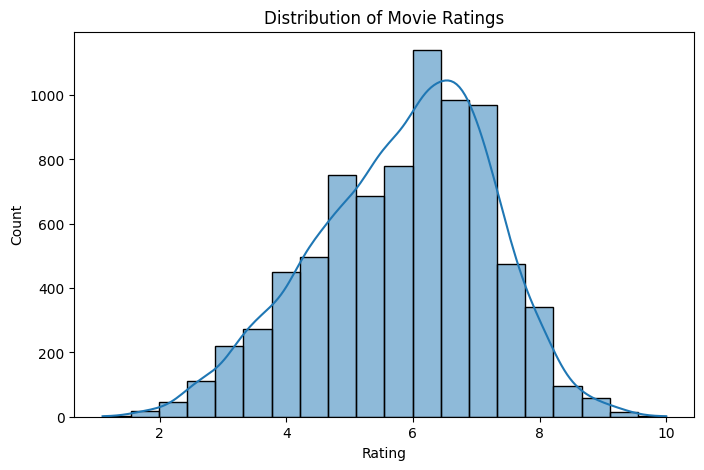

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.show()

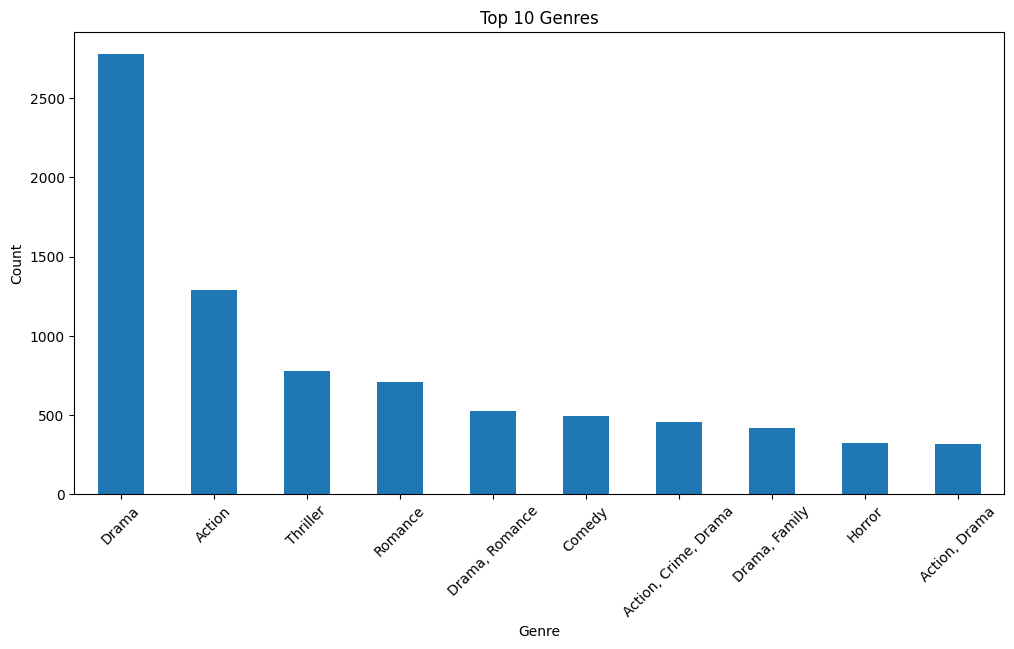

In [ ]:
plt.figure(figsize=(12,6))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

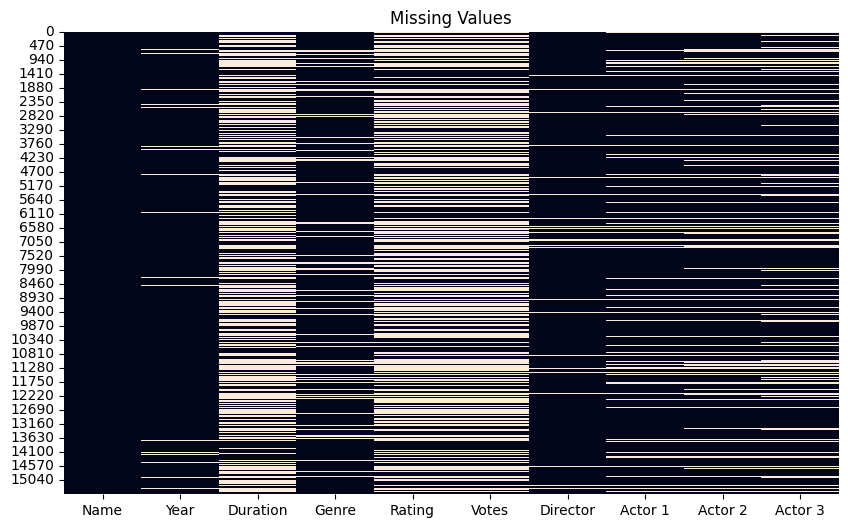

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [ ]:
# Remove duplicate records
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (15503, 10)


In [ ]:
# Remove rows where Rating is missing
df = df.dropna(subset=['Rating'])

print("Dataset Shape:", df.shape)

Dataset Shape: (7919, 10)


In [ ]:
df.isnull().sum()

,0
Name,0
Year,0
Duration,2068
Genre,102
Rating,0
Votes,0
Director,5
Actor 1,125
Actor 2,200
Actor 3,292


In [ ]:
# Remove brackets from Year
df['Year'] = df['Year'].str.extract('(\d{4})')

# Convert to numeric
df['Year'] = pd.to_numeric(df['Year'])

In [ ]:
# Remove "min" from Duration
df['Duration'] = df['Duration'].str.replace('min', '', regex=False)

# Convert to numeric
df['Duration'] = pd.to_numeric(df['Duration'])

In [ ]:
# Remove commas from Votes
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)

# Convert to numeric
df['Votes'] = pd.to_numeric(df['Votes'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   float64
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   int64  
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 680.5+ KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   float64
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   int64  
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 680.5+ KB


In [ ]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


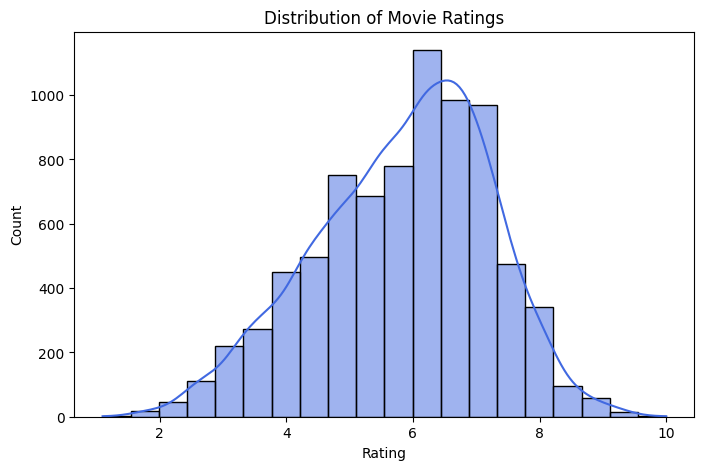

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=20, kde=True, color="royalblue")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

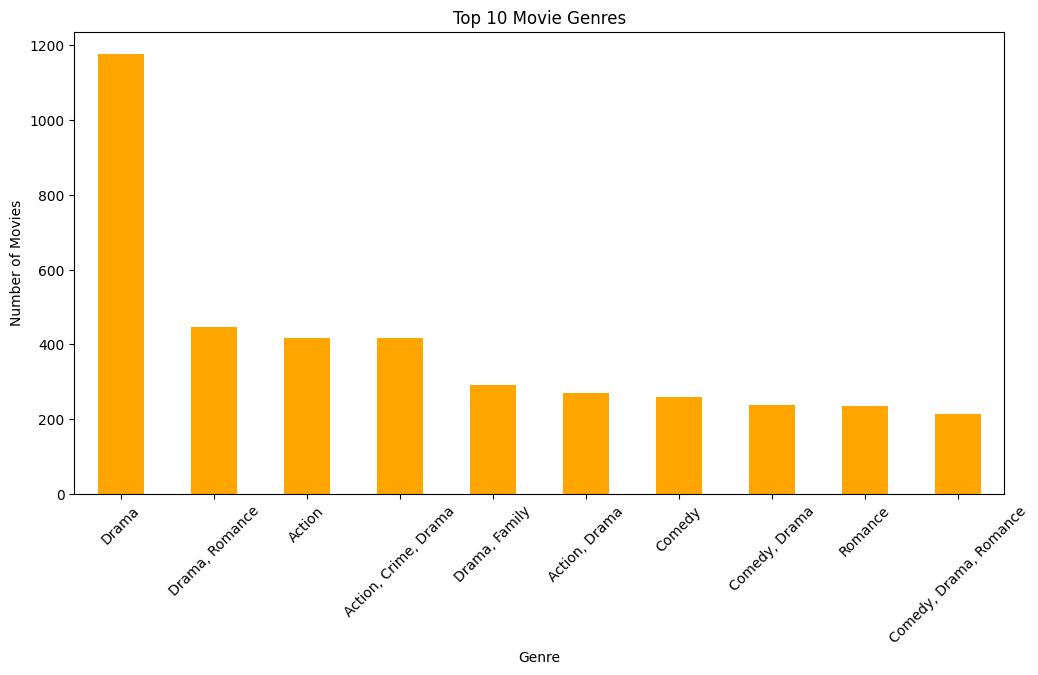

In [ ]:
plt.figure(figsize=(12,6))

df["Genre"].value_counts().head(10).plot(kind="bar", color="orange")

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

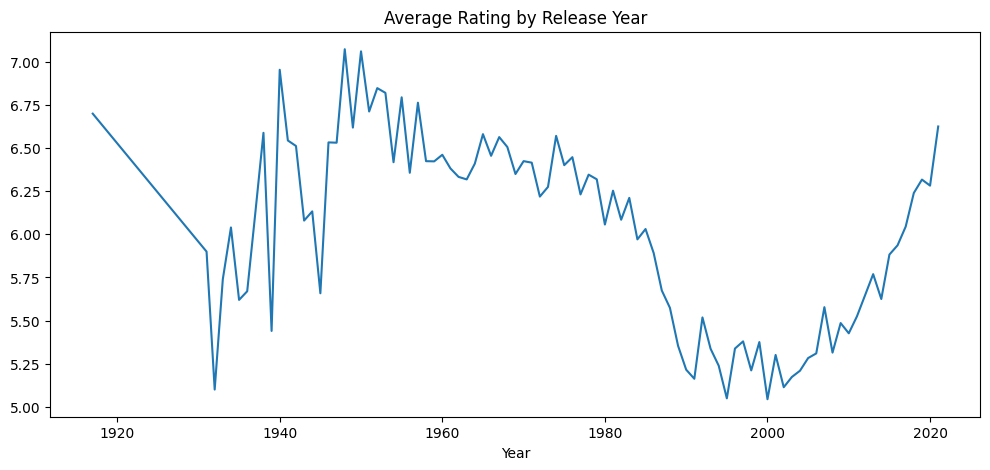

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=df.groupby("Year")["Rating"].mean().index,
    y=df.groupby("Year")["Rating"].mean().values
)

plt.title("Average Rating by Release Year")

plt.show()

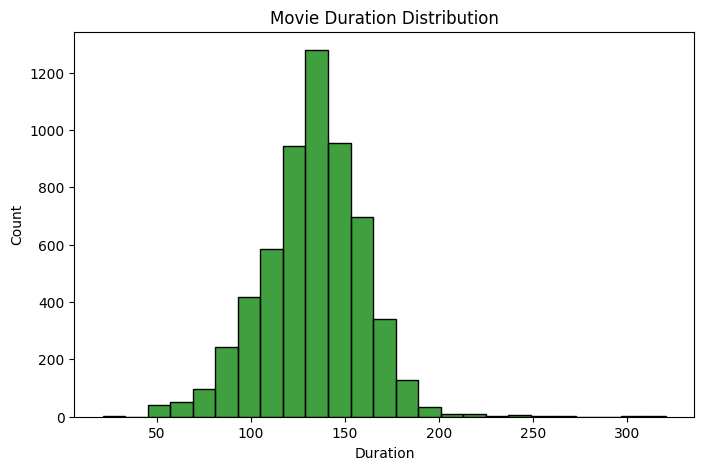

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Duration"], bins=25, color="green")

plt.title("Movie Duration Distribution")

plt.show()

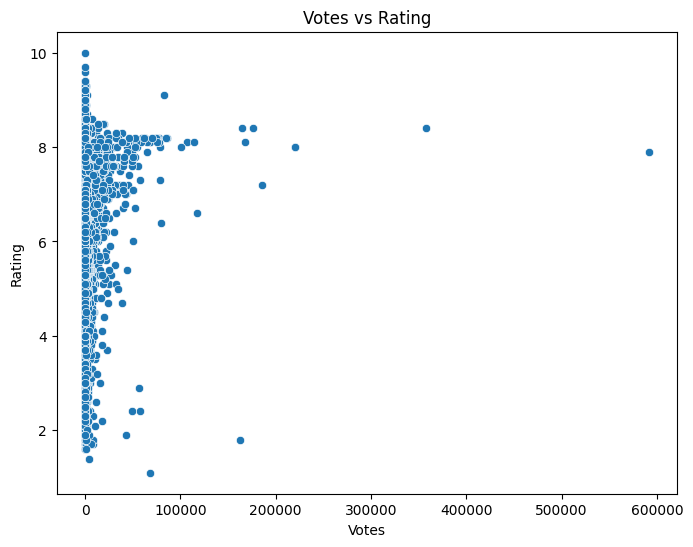

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="Votes",
                y="Rating")

plt.title("Votes vs Rating")

plt.show()

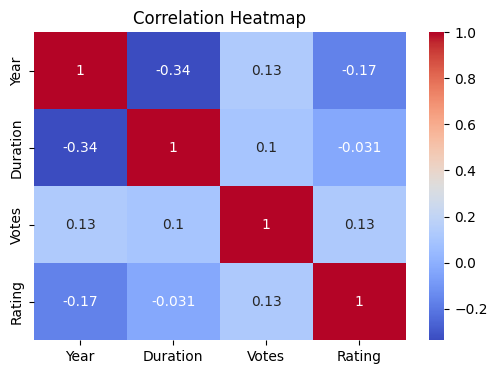

In [ ]:
plt.figure(figsize=(6,4))

numeric_df = df[['Year','Duration','Votes','Rating']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Select input features
X = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3',
        'Year', 'Duration', 'Votes']]

# Target variable
y = df['Rating']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (6335, 8)
Testing Samples: (1584, 8)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

numeric_features = [
    'Year',
    'Duration',
    'Votes'
]

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', categorical_transformer, categorical_features),
    ('num', numeric_transformer, numeric_features)
])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Genre', 'Director',
                                                   'Actor 1', 'Actor 2',
                                                   'Actor 3']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Year', 'Duration',
                                                   'Votes'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [ ]:
predictions = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 0.799315025252525
Root Mean Squared Error : 1.0771522434142835
R2 Score : 0.375919109203368


In [ ]:
import pandas as pd

feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

importance = rf_model.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
10353,num__Votes,0.200039
10351,num__Year,0.176200
10352,num__Duration,0.073626
236,cat__Genre_Drama,0.022012
213,cat__Genre_Documentary,0.017398
9281,cat__Actor 3_Pran,0.011518
324,cat__Genre_Horror,0.005485
6984,cat__Actor 2_Rekha,0.004516
0,cat__Genre_Action,0.003564
249,"cat__Genre_Drama, Family",0.002898


In [ ]:
import joblib

joblib.dump(rf_model, "movie_rating_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.799315,1.077152,0.375919
4,Extra Trees,0.799754,1.081300,0.371103
3,Gradient Boosting,0.857280,1.115730,0.330416
0,Linear Regression,0.947760,1.208530,0.214400
1,Decision Tree,1.018624,1.376487,-0.019133


In [ ]:
# Sample movie data for prediction

sample_movie = pd.DataFrame({
    'Genre': ['Drama'],
    'Director': ['Gaurav Bakshi'],
    'Actor 1': ['Rasika Dugal'],
    'Actor 2': ['Vivek Ghamande'],
    'Actor 3': ['Arvind Jangid'],
    'Year': [2019],
    'Duration': [109],
    'Votes': [8]
})

# Predict rating
predicted_rating = rf_model.predict(sample_movie)

print("Predicted Movie Rating:", round(predicted_rating[0], 2))

Predicted Movie Rating: 7.32


In [ ]:
# Compare actual and predicted ratings

comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': predictions
})

comparison.head(10)

,Actual Rating,Predicted Rating
0,3.3,3.6380
1,5.3,5.2505
2,5.7,6.0035
3,7.2,6.6340
4,3.5,5.5955
5,7.2,6.4545
6,3.8,5.1550
7,6.9,6.8260
8,5.2,5.7060
9,7.4,6.3490


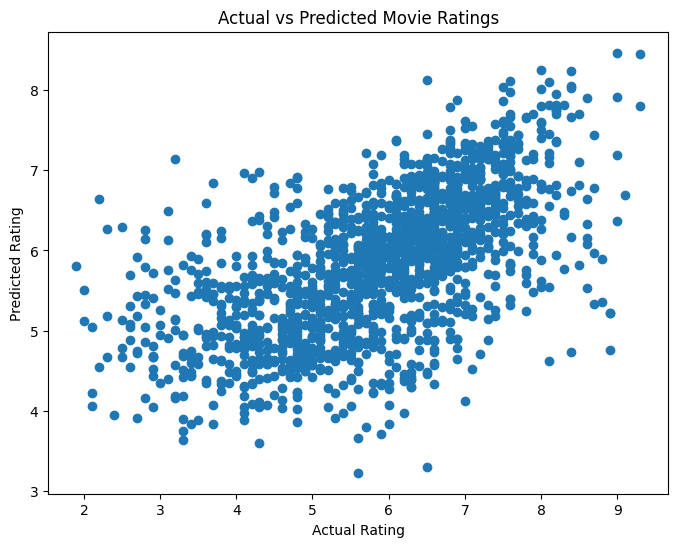

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

In [ ]:
import joblib

joblib.dump(rf_model, "movie_rating_model.pkl")

print("Model saved successfully!")

Model saved successfully!
